In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import distributions as torchd
from torch.utils.tensorboard import SummaryWriter
import torch.distributions as dist
from collections import defaultdict
import matplotlib.pyplot as plt
import pathlib
from dreamer import Dreamer, count_steps, make_dataset, make_env
import tools
import ruamel.yaml as yaml
import argparse
from parallel import Parallel, Damy
import glob
import sys
import os
import json
import re

from scipy.stats import f_oneway, ttest_ind
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

## Agent loading (No execution required)

In [ ]:
sys_argv = [
    "--configs", "atari100k",
    "--task", "atari_pong",
    '--device','cpu',
    "--logdir", "./behavior_data_processed_4kframe/sub_1/test/pong/td3",
    "--traindir", "./behavior_data_processed_4kframe/sub_1/game_1"
]

# argparse 초기화
parser = argparse.ArgumentParser()
parser.add_argument("--configs", nargs="+")
args, remaining = parser.parse_known_args(sys_argv)

# YAML 파일 로드
configs_path = pathlib.Path.cwd() / "configs.yaml"
configs = yaml.safe_load(configs_path.read_text())

def recursive_update(base, update):
    for key, value in update.items():
        if isinstance(value, dict) and key in base:
            recursive_update(base[key], value)
        else:
            base[key] = value

name_list = ["defaults", *args.configs] if args.configs else ["defaults"]
defaults = {}
for name in name_list:
    recursive_update(defaults, configs[name])
parser = argparse.ArgumentParser()
for key, value in sorted(defaults.items(), key=lambda x: x[0]):
    arg_type = tools.args_type(value)
    parser.add_argument(f"--{key}", type=arg_type, default=arg_type(value))

In [ ]:
config = parser.parse_args(remaining)

In [ ]:
tools.set_seed_everywhere(config.seed)
if config.deterministic_run:
    tools.enable_deterministic_run()
logdir = pathlib.Path(config.logdir).expanduser()
config.traindir = config.traindir or logdir / "train_eps"
config.evaldir = config.evaldir or logdir / "eval_eps"
config.steps #//= config.action_repeat
config.eval_every #//= config.action_repeat
config.log_every #//= config.action_repeat
config.time_limit #//= config.action_repeat

print("Logdir", logdir)
logdir.mkdir(parents=True, exist_ok=True)
if type(config.traindir) == str:
    config.traindir = pathlib.Path(config.traindir).expanduser()
if type(config.evaldir) == str:
    config.evaldir = pathlib.Path(config.evaldir).expanduser()
config.traindir.mkdir(parents=True, exist_ok=True)
config.evaldir.mkdir(parents=True, exist_ok=True)

pathlib.Path(config.traindir).expanduser().mkdir(parents=True, exist_ok=True)

if os.path.isfile(os.path.join(config.logdir, "metrics.jsonl")):
    logger_file_path = config.logdir + '/metrics.jsonl'
    with open(logger_file_path, 'r')as file:
        last_value = None
        for line in file:
            if line != None:
                data = json.loads(line)
                last_value = data
    step = last_value.get('step')
    step #//= config.action_repeat
else:
    # step = count_steps(config.traindir)
    step = 0

logger = tools.Logger(logdir, step)

# environment creating
print("Create envs.")
if config.offline_traindir:
    directory = config.offline_traindir.format(**vars(config))
else:
    directory = config.traindir
train_eps = tools.load_episodes(directory, limit=config.dataset_size)
if config.offline_evaldir:
    directory = config.offline_evaldir.format(**vars(config))
else:
    directory = config.evaldir
eval_eps = tools.load_episodes(directory, limit=1)
make = lambda mode, id: make_env(config, mode, id)
train_envs = [make("train", i) for i in range(config.envs)]
eval_envs = [make("eval", i) for i in range(config.envs)]
if config.parallel:
    train_envs = [Parallel(env, "process") for env in train_envs]
    eval_envs = [Parallel(env, "process") for env in eval_envs]
else:
    train_envs = [Damy(env) for env in train_envs]
    eval_envs = [Damy(env) for env in eval_envs]
acts = train_envs[0].action_space
print("Action Space", acts)
config.num_actions = acts.n if hasattr(acts, "n") else acts.shape[0]

In [ ]:
print("Simulate agent.")

#TODO: make function to make dataset of human behavioral data
train_dataset = make_dataset(train_eps, config)
eval_dataset = make_dataset(eval_eps, config)

agent = Dreamer(train_envs[0].observation_space,
        train_envs[0].action_space,
        config,
        logger,
        train_dataset,).to(config.device)

agent.requires_grad_(requires_grad=False)

pt_files = glob.glob(str(logdir / "*.pt"))
if pt_files:
    latest_pt_file = max(pt_files, key=os.path.getmtime)
    checkpoint = torch.load(latest_pt_file)
    agent.load_state_dict(checkpoint["agent_state_dict"])
    tools.recursively_load_optim_state_dict(agent, checkpoint["optims_state_dict"])
    agent._should_pretrain._once = False

## DTW IMPLEMENT

In [ ]:
def dtw(one_hot_seq1, one_hot_seq2):
    """
    Compute the Dynamic Time Warping (DTW) distance between two sequences of one-hot encoded vectors.
    
    Args:
        one_hot_seq1 (torch.Tensor): Tensor of shape (L, action_number).
        one_hot_seq2 (torch.Tensor): Tensor of shape (M, action_number).
        
    Returns:
        float: The DTW distance between the two sequences.
    """
    L, action_number1 = one_hot_seq1.shape
    M, action_number2 = one_hot_seq2.shape
    
    # Ensure both sequences have the same action dimension
    assert action_number1 == action_number2, "Both sequences must have the same action dimension."

    # Initialize the L x M cost matrix with infinity
    cost_matrix = np.full((L, M), np.inf)
    
    # Initialize the (0, 0) position
    cost_matrix[0, 0] = 0 if torch.equal(one_hot_seq1[0], one_hot_seq2[0]) else 1
    
    # Fill the cost matrix
    for l in range(1, L):
        cost_matrix[l, 0] = cost_matrix[l-1, 0] + (0 if torch.equal(one_hot_seq1[l], one_hot_seq2[0]) else 1)
    
    for m in range(1, M):
        cost_matrix[0, m] = cost_matrix[0, m-1] + (0 if torch.equal(one_hot_seq1[0], one_hot_seq2[m]) else 1)
    
    for l in range(1, L):
        for m in range(1, M):
            # Calculate the cost: 0 if equal, 1 if not
            cost = 0 if torch.equal(one_hot_seq1[l], one_hot_seq2[m]) else 1
            # The current cell in cost matrix is updated based on the minimum of three possible moves:
            cost_matrix[l, m] = cost + min(cost_matrix[l-1, m],   # insertion
                                           cost_matrix[l, m-1],   # deletion
                                           cost_matrix[l-1, m-1]) # match
    # The DTW distance is the value in the bottom-right of the cost matrix
    dtw_distance = cost_matrix[L-1, M-1]
    return dtw_distance

In [ ]:

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# 결과를 저장할 딕셔너리 초기화
results = defaultdict(list)

# action_number와 agent._config.device 정의
device = "cuda:0"  # agent._config.device로 설정

# 처리할 디렉토리 목록
dirs_to_process = [
    pathlib.Path("./logdir/atari_enduro_0/train_eps"),
    pathlib.Path("./logdir/atari_pong_0/train_eps"),
    pathlib.Path("./logdir/atari_space_invaders_0/train_eps"),
]

# 각 디렉토리의 npz 파일을 탐색
for base_path in dirs_to_process:
    for npz_file in base_path.glob("*.npz"):
        try:
            with npz_file.open("rb") as f:
                episode = np.load(f)
                episode = {k: np.expand_dims(episode[k], axis=0) for k in episode.keys()}
        except Exception as e:
            print(f"Error loading {npz_file}: {e}")
            continue
        
        # behavior 텐서로 변환
        behavior = torch.Tensor(episode['action'].squeeze(0)).to(device)
        action_number = behavior.shape[-1]
        
        # behavior와 동일한 크기의 random one-hot 텐서 생성
        random_actions = torch.nn.functional.one_hot(
            torch.randint(0, action_number, (behavior.shape[0],)),
            num_classes=action_number
        ).float().to(device)
        
        # 0부터 action_number-1까지의 특정 action만 취하는 텐서들 생성
        fixed_actions = []
        for i in range(action_number):
            fixed_action = torch.nn.functional.one_hot(
                torch.full((behavior.shape[0],), i),
                num_classes=action_number
            ).float().to(device)
            fixed_actions.append(fixed_action)
        print(behavior.shape)
        print(random_actions.shape)
        # dtw 결과 계산 (dtw 함수는 이미 구현되어 있어야 함)
        dtw_results = {
            'random': dtw(behavior, random_actions),
        }
        for i, fixed_action in enumerate(fixed_actions):
            dtw_results[f'fixed_{i}'] = dtw(behavior, fixed_action)
        
        # 결과를 리스트에 추가
        for key, value in dtw_results.items():
            results[key].append(value)

    # 결과 파일 저장
    result_file_name = f"dtw_results_{base_path.parent.name}.npz"  # 상위 디렉토리 이름 추가
    result_file = base_path.parent / result_file_name
    np.savez(result_file, **results)
    print(f"Results saved to {result_file}")


## COSINE SIMILARITY IMPLEMENT

In [ ]:
'''
agent가 얼마나 dataset의 behavior를 잘 추종하는지 평가하기 위해 
훈련에 사용된 dataset 중 100 length의 데이터 fragment 50개를 sample하는 코드.
샘플된 데이터는 dataset 디렉토리의 parent 디렉토리에 sample_data_XXXX.npz 파일로 저장됨.
주어진 데이터셋의 sample할 때만 주석을 풀고 사용하시면 됩니다.
'''
# import os
# import pathlib
# import numpy as np
# from collections import defaultdict

# # Directories to process
# dirs_to_process = [
#     pathlib.Path("./behavior_data_processed_4kframe/sub_1/game_0"),
#     pathlib.Path("./behavior_data_processed_4kframe/sub_1/game_1"),
#     pathlib.Path("./behavior_data_processed_4kframe/sub_1/game_2"),
# ]

# # Process each directory
# for base_path in dirs_to_process:
#     concatenated_data = defaultdict(list)
    
#     # Load and concatenate data from each npz file
#     for npz_file in base_path.glob("*.npz"):
#         try:
#             with npz_file.open("rb") as f:
#                 episode = np.load(f)
#                 for key in episode.keys():
#                     concatenated_data[key].append(episode[key])
#         except Exception as e:
#             print(f"Error loading {npz_file}: {e}")
#             continue

#     # Concatenate all data by key
#     concatenated_data = {k: np.concatenate(v, axis=0) for k, v in concatenated_data.items()}

#     # Randomly sample 50 segments of length 100 from each key
#     num_samples = 50
#     sample_length = 100
#     sampled_data = {}
#     total_length = concatenated_data[list(concatenated_data.keys())[0]].shape[0]
#     indices = np.random.choice(total_length - sample_length + 1, num_samples, replace=False)

#     for key in concatenated_data.keys():
#         sampled_data[key] = np.stack([concatenated_data[key][i:i+sample_length] for i in indices])

#     # Save the sampled data
#     result_file_name = f"sampled_data_{base_path.name}.npz"
#     result_file = base_path.parent / result_file_name
#     np.savez(result_file, **sampled_data)
#     print(f"Sampled data saved to {result_file}")

In [ ]:
def actor_eval_cosine(agent, logdir=None, directory=None, is_save=False):
    '''
    
    '''
    if directory is None:
        directory = agent._config.traindir

    directory = pathlib.Path(directory)  # Ensure `directory` is a Path object

    # List to store the cosine distance results
    cosine_results = []

    # Find the file with "sampled_data" and matching game name in its name
    sampled_file = None
    game_name = directory.name  # Extract the game name from the directory path

    for filename in directory.parent.glob("sampled_data_*.npz"):  # Match "sampled_data_*.npz"
        print(filename)
        if game_name in filename.stem:  # Check if the game name is in the file stem
            sampled_file = filename
            break

    if sampled_file is None:
        print("No file containing 'sampled_data' and matching the game name found in the directory.")
        return cosine_results  # Return empty list if no file is found

    # Load and process the "sampled_data" file
    try:
        with sampled_file.open("rb") as f:
            episode = np.load(f)
            episode = {k: episode[k] for k in episode.keys()}
    except Exception as e:
        print(f"Could not load episode {sampled_file}: {e}")
        return cosine_results  # Return empty list if file loading fails

    # Convert action data to tensor
    behavior = torch.Tensor(episode['action']).to(agent._config.device)
    episode = agent._wm.preprocess(episode)
    embed = agent._wm.encoder(episode)

    latent, _ = agent._wm.dynamics.observe(embed, episode["action"], episode["is_first"])

    feat = agent._wm.dynamics.get_feat(latent)

    actor = agent._task_behavior.actor(feat)
    action = actor.mode()

    print(behavior.shape)
    print(action.shape)
    # Get sampled action from the agent
    
    # Calculate cosine similarity
    cosine_distance = torch.nn.functional.cosine_similarity(behavior, action, dim=-1).mean(dim=1)

    # Convert the results list to a numpy array
    cosine_results = cosine_distance.cpu().numpy()
    if is_save:
        # Extract the directory name to include in the file name
        directory_name = logdir.name  # This gives "atari_space_invaders_humanbehavior0_imit0_1"

        # Construct the result file name using the directory name
        result_file_name = f"cosine_similarity_{directory_name}.npy"
        
        # Save the file in the specified directory
        result_file = logdir.parent / result_file_name
        np.save(result_file, cosine_results)
        print(f"Sampled data saved to {result_file}")
    return cosine_results

In [ ]:
'''
main_directory 내의 모든 실행 결과들을 순회하며 특정 epoch만큼 훈련시킨 agent를 호출, actor network가 얼마나 주어진 dataset의 behavior의 행동을 reproduce하는지 평가함.
'''
from pathlib import Path

# variables
main_directory = Path("./behavior_data_processed_4kframe/sub_1/test") #내부 디렉토리를 순회시킬 main directory 설정.
task = "space_invaders"
agent_directory = "./behavior_data_processed_4kframe/sub_1/game_2"
train_epoch = 70000

def detect_atari_game(input_str):
    """
    특정 키워드가 포함된 경우 대응하는 "atari_<game>" 문자열을 반환하는 함수
    """
    keywords = {
        "enduro": "atari_enduro",
        "game_0": "atari_enduro",
        "pong": "atari_pong",
        "game_1": "atari_pong",
        "space_invaders": "space_invaders",
        "game_2": "space_invaders"
    }

    # 입력 문자열이 키워드 중 하나를 포함하는지 확인
    for key, value in keywords.items():
        if key in input_str.lower():  # 대소문자 구분 없이 검색
            return value



# Loop through directories containing "test_" in their name
for directory in main_directory.iterdir():
    if directory.is_dir() and task in directory.name: # task가 바뀌면 "enduro", "pong" 으로 수정해야합니다.
        atari_task = detect_atari_game(directory.name)
        for sub_dir in directory.iterdir():
            imit_algo = "bc" if sub_dir.name=="bc" else "TD3"
            sys_argv = [
                "--configs", "atari100k",
                "--task", atari_task,
                '--device','cuda:0',
                "--logdir", str(sub_dir),
                "--traindir", agent_directory
                # 아래의 부분은 training 시에 필요한 argument이므로 수정하지 않으셔도 됩니다.
                "--is_imit", "True",
                "--rollout_train_start", "0.5",
                "--seed", "0",
                "--prediction_strategy", "none",
                "--imit_start", "0",
                "--imit_algo", imit_algo #str(sub_dir.name)
            ]

            # argparse 초기화
            parser = argparse.ArgumentParser()
            parser.add_argument("--configs", nargs="+")
            args, remaining = parser.parse_known_args(sys_argv)

            # YAML 파일 로드
            configs_path = pathlib.Path.cwd() / "configs.yaml"
            configs = yaml.safe_load(configs_path.read_text())

            def recursive_update(base, update):
                for key, value in update.items():
                    if isinstance(value, dict) and key in base:
                        recursive_update(base[key], value)
                    else:
                        base[key] = value

            name_list = ["defaults", *args.configs] if args.configs else ["defaults"]
            defaults = {}
            for name in name_list:
                recursive_update(defaults, configs[name])
            parser = argparse.ArgumentParser()
            for key, value in sorted(defaults.items(), key=lambda x: x[0]):
                arg_type = tools.args_type(value)
                parser.add_argument(f"--{key}", type=arg_type, default=arg_type(value))
            config = parser.parse_args(remaining)
            tools.set_seed_everywhere(config.seed)
            if config.deterministic_run:
                tools.enable_deterministic_run()
            logdir = pathlib.Path(config.logdir).expanduser()
            config.traindir = config.traindir or logdir / "train_eps"
            config.evaldir = config.evaldir or logdir / "eval_eps"
            config.steps #//= config.action_repeat
            config.eval_every #//= config.action_repeat
            config.log_every #//= config.action_repeat
            config.time_limit #//= config.action_repeat

            print("Logdir", logdir)
            logdir.mkdir(parents=True, exist_ok=True)
            if type(config.traindir) == str:
                config.traindir = pathlib.Path(config.traindir).expanduser()
            if type(config.evaldir) == str:
                config.evaldir = pathlib.Path(config.evaldir).expanduser()
            config.traindir.mkdir(parents=True, exist_ok=True)
            config.evaldir.mkdir(parents=True, exist_ok=True)

            pathlib.Path(config.traindir).expanduser().mkdir(parents=True, exist_ok=True)

            if os.path.isfile(os.path.join(config.logdir, "metrics.jsonl")):
                logger_file_path = config.logdir + '/metrics.jsonl'
                with open(logger_file_path, 'r')as file:
                    last_value = None
                    for line in file:
                        if line != None:
                            data = json.loads(line)
                            last_value = data
                step = last_value.get('step')
                step #//= config.action_repeat
            else:
                # step = count_steps(config.traindir)
                step = 0

            logger = tools.Logger(logdir, step)

            # environment creating
            print("Create envs.")
            if config.offline_traindir:
                directory = config.offline_traindir.format(**vars(config))
            else:
                directory = config.traindir
            train_eps = tools.load_episodes(directory, limit=config.dataset_size)
            if config.offline_evaldir:
                directory = config.offline_evaldir.format(**vars(config))
            else:
                directory = config.evaldir
            eval_eps = tools.load_episodes(directory, limit=1)
            make = lambda mode, id: make_env(config, mode, id)
            train_envs = [make("train", i) for i in range(config.envs)]
            eval_envs = [make("eval", i) for i in range(config.envs)]
            if config.parallel:
                train_envs = [Parallel(env, "process") for env in train_envs]
                eval_envs = [Parallel(env, "process") for env in eval_envs]
            else:
                train_envs = [Damy(env) for env in train_envs]
                eval_envs = [Damy(env) for env in eval_envs]
            acts = train_envs[0].action_space
            print("Action Space", acts)
            config.num_actions = acts.n if hasattr(acts, "n") else acts.shape[0]
            print("Simulate agent.")

            #TODO: make function to make dataset of human behavioral data
            train_dataset = make_dataset(train_eps, config)
            eval_dataset = make_dataset(eval_eps, config)

            agent = Dreamer(train_envs[0].observation_space,
                    train_envs[0].action_space,
                    config,
                    logger,
                    train_dataset,).to(config.device)

            agent.requires_grad_(requires_grad=False)

            pt_files = glob.glob(str(logdir / f"*{train_epoch}.pt"))
            if pt_files:
                latest_pt_file = pt_files[0]
                checkpoint = torch.load(latest_pt_file)
                agent.load_state_dict(checkpoint["agent_state_dict"])

                tools.recursively_load_optim_state_dict(agent, checkpoint["optims_state_dict"])
                agent._should_pretrain._once = False
            
            cosine_results = actor_eval_cosine(agent, logdir = logdir, directory=None, is_save=True)
            print(cosine_results)

Logdir behavior_data_processed_4kframe/sub_1/test/space_invaders/TD3
Create envs.
Action Space Box(0.0, 1.0, (6,), float32)
Simulate agent.
Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}
Optimizer model_opt has 15687811 variables.
Optimizer actor_opt has 1053702 variables.
Optimizer value_opt has 1181439 variables.
behavior_data_processed_4kframe/sub_1/sampled_data_game_1.npz
behavior_data_processed_4kframe/sub_1/sampled_data_game_0.npz
behavior_data_processed_4kframe/sub_1/sampled_data_game_2.npz
torch.Size([50, 100, 6])
torch.Size([50, 100, 6])
Sampled data saved to behavior_data_processed_4kframe/sub_1/test/space_invaders/cosine_similarity_TD3.npy
[0.75       0.77       0.69       0.9        0.75       0.93
 0.91999996 0.82       0.9        0.88       0.75       0.84999996
 0.84       0.88       0.71999997 0.72999996 0.78999996 0.90999997
 0.72999996 0.84999996 0.81       0.72999996 0.72999996 0.88


In [ ]:
'''
agent 간의 dataset behavior reproductivity 비교에 필요한 function 정리.
'''
from scipy.stats import ttest_ind, sem
# Define helper functions (as in your original code)
def calculate_cosine_similarity(action, comparison_actions):
    action_tensor = torch.tensor(action, dtype=torch.float32)
    similarities = []
    for comp_action in comparison_actions:
        comp_action_tensor = torch.tensor(comp_action, dtype=torch.float32)
        similarity = torch.nn.functional.cosine_similarity(action_tensor, comp_action_tensor, dim=-1).mean(dim=1)
        similarities.append(similarity.cpu().numpy())
    return np.stack(similarities, axis=0)

def generate_comparison_actions(action_shape):
    n_samples, seq_len, n_action = action_shape
    random_action = np.random.randint(0, n_action, (n_samples, seq_len))
    random_action_onehot = np.eye(n_action)[random_action]
    fixed_actions = [np.eye(n_action)[np.full((n_samples, seq_len), i)] for i in range(n_action)]
    return [random_action_onehot] + fixed_actions

def plot_cosine_similarity(ax, similarities, labels, title=None, baseline_label="Baseline", bar_width=0.4):
    """
    Display mean cosine similarities for baseline actions as horizontal dotted lines
    and bar plot for imitation actions with significance markers based on p-values.
    """
    colors = ["red", "blue"]

    # Calculate yerr (95% confidence interval)
    def calculate_ci(data):
        mean = np.mean(data)
        error_margin = sem(data) * 1.96  # 95% CI
        return mean, error_margin

    # Plot bar plots for imit0 and imit1 actions
    bar_positions = []
    bar_heights = []  # Store bar heights for significance line positioning
    for i, group in enumerate(similarities[1:], start=1):
        mean_similarity, ci = calculate_ci(group.flatten())
        bar = ax.bar(labels[i - 1], mean_similarity, yerr=ci, color=colors[i - 1], alpha=0.7, width=bar_width)
        bar_positions.append(bar[0].get_x() + bar[0].get_width() / 2)
        bar_heights.append(mean_similarity + ci)

    # Add significance markers between bars
    significance_levels = {0.001: '***', 0.01: '**', 0.05: '*', float('inf'): 'ns'} 
    y_offset = 0.02  # Offset for horizontal line above the bars
    line_height = 0.03  # Height of the significance line

    def add_significance(ax, x1, x2, y, p_value):
        """
        Add significance markers between two bars.
        """
        # Find the correct significance marker
        marker = ''
        for threshold, symbol in significance_levels.items():
            if p_value < threshold:  # Check thresholds in ascending order
                marker = symbol
                break  # Stop at the first match

        if marker:
            # Draw horizontal line
            ax.plot([x1, x1, x2, x2], [y, y + line_height, y + line_height, y], color='black', lw=1.5)
            # Add marker
            ax.text((x1 + x2) / 2, y + line_height, marker, ha='center', va='bottom', color='black')

    # Perform t-tests between each pair of bars and add significance
    for i in range(len(similarities[1:]) - 1):
        group1 = similarities[1:][i].flatten()  # Access the i-th group in similarities[1:]
        group2 = similarities[1:][i + 1].flatten()  # Access the next group
        t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
        print(p_value)
        add_significance(ax, bar_positions[i], bar_positions[i + 1], max(bar_heights[i], bar_heights[i + 1]) + y_offset, p_value)

    # Plot horizontal lines for baseline actions only over the width of individual bars
    for i, baseline_action in enumerate(similarities[0]):
        mean_similarity = baseline_action.mean()
        for bar_x in bar_positions:
            ax.hlines(y=mean_similarity,
                      xmin=bar_x - bar_width / 2,  # Start at left edge of the bar
                      xmax=bar_x + bar_width / 2,  # End at right edge of the bar
                      color=f'C{i}', linestyle=':', label=f'{baseline_label} Action {i + 1}' if bar_x == bar_positions[0] else "")

    # Perform t-tests and add significance markers
    y_offset = 0.02

    for i, group in enumerate(similarities[1:], start=1):
        mean_similarity = group.mean()

        # Calculate p-values for each baseline action
        p_values = []
        for baseline_action in similarities[0]:
            t_stat, p_value = ttest_ind(baseline_action.flatten(), group.flatten(), equal_var=False)
            p_values.append(p_value)

        # Use the maximum p-value from all comparisons
        # max_p_value = max(p_values)
        # print(max_p_value)
        marker = ''
        # for threshold, symbol in significance_levels.items():
        #     if max_p_value < threshold:
        #         marker = symbol
        #         break

        # Add marker to the plot if any significance level is met
        if marker:
            ax.text(bar_positions[i - 1], mean_similarity + y_offset, marker,
                    ha='center', va='bottom', fontsize=12, color='black')


    # Labels, title, and legend
    ax.set_ylim([0, 1.5])
    ax.set_ylabel("Mean Cosine Similarity")
    ax.set_title(title)
    # ax.legend()


[0.12 0.07 0.1  0.11 0.08 0.15 0.09 0.09 0.11 0.19 0.13 0.08 0.12 0.08
 0.16 0.1  0.16 0.16 0.08 0.09 0.16 0.08 0.1  0.11 0.13 0.14 0.15 0.15
 0.05 0.13 0.09 0.09 0.12 0.1  0.13 0.09 0.11 0.06 0.1  0.12 0.08 0.1
 0.15 0.06 0.2  0.1  0.11 0.12 0.02 0.16 0.11 0.1  0.09 0.05 0.08 0.08
 0.09 0.16 0.09 0.14 0.07 0.1  0.19 0.11 0.13 0.17 0.09 0.08 0.12 0.1
 0.14 0.13 0.1  0.15 0.09 0.1  0.1  0.1  0.12 0.07 0.11 0.1  0.07 0.1
 0.06 0.2  0.17 0.07 0.15 0.09 0.1  0.1  0.1  0.08 0.07 0.07 0.17 0.09
 0.08 0.09 0.11 0.07 0.11 0.11 0.12 0.1  0.09 0.13 0.1  0.15 0.15 0.15
 0.13 0.11 0.08 0.09 0.11 0.14 0.11 0.1  0.15 0.12 0.1  0.09 0.13 0.11
 0.14 0.12 0.12 0.13 0.1  0.11 0.1  0.09 0.12 0.1  0.05 0.12 0.08 0.16
 0.1  0.09 0.07 0.15 0.09 0.18 0.06 0.1  0.06 0.09 0.12 0.1  0.13 0.12
 0.11 0.18 0.13 0.08 0.08 0.13 0.11 0.12 0.05 0.06 0.12 0.14 0.1  0.15
 0.11 0.08 0.08 0.12 0.16 0.07 0.13 0.18 0.03 0.09 0.08 0.13 0.15 0.16
 0.09 0.08 0.08 0.07 0.05 0.09 0.1  0.14 0.05 0.13 0.07 0.07 0.07 0.13
 0.15 0.1

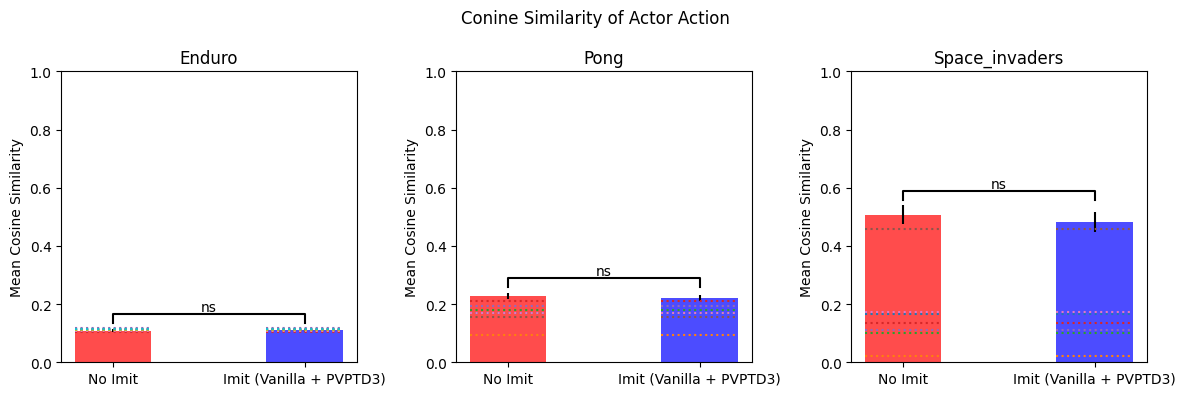

In [ ]:
'''
각 task에 대한 dataset behavior reproductivity plot.
For simulated dataset.
'''
games = ["enduro", "pong", "space_invaders"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # Create a 1x3 subplot

for idx, game_name in enumerate(games):
    # Construct file paths dynamically
    baseline_filepath = f"./logdir/atari_{game_name}_0/sampled_data_atari_{game_name}_0.npz"
    main_directory = f"./logdir/test/{game_name}"

    # Load baseline data and calculate similarities
    data = np.load(baseline_filepath)
    action = data['action']
    n_action = action.shape[-1]
    comparison_actions = generate_comparison_actions(action.shape)
    baseline_similarities = calculate_cosine_similarity(action, comparison_actions)

    # Load imit0 and imit1 groups
    imit0_files = sorted(glob.glob(os.path.join(main_directory, "*imit0*.npy")))
    imit1_files = sorted(glob.glob(os.path.join(main_directory, "*imit1*.npy")))
    imit0_group = np.concatenate([np.load(f) for f in imit0_files], axis=0)
    imit1_group = np.concatenate([np.load(f) for f in imit1_files], axis=0)

    # Prepare data for plotting
    all_similarities = [baseline_similarities] + [imit0_group, imit1_group]
    labels = ['No Imit', 'Imit (Vanilla + PVPTD3)']
    title = f"{game_name.capitalize()}"

    # Plot for the current game
    plot_cosine_similarity(axes[idx], all_similarities, labels, title)
    plt.rc("legend", fontsize=8)

# Adjust layout and show the plot
fig.suptitle("Conine Similarity of Actor Action")
plt.tight_layout()
plt.show()

1.8632614815063528e-56
5.588546224215804e-33
1.0788025741171106e-47


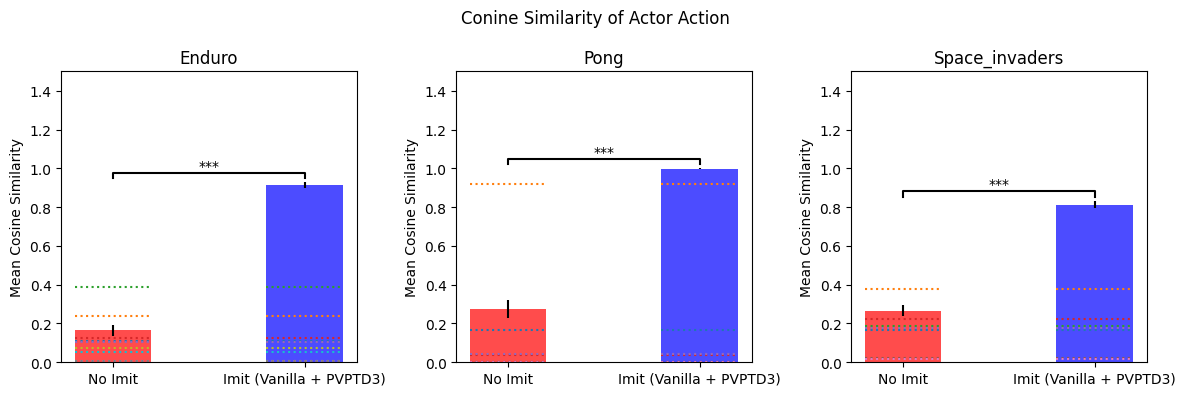

In [ ]:
'''
각 task에 대한 dataset behavior reproductivity plot.
For human dataset.
'''
games = ["enduro", "pong", "space_invaders"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # Create a 1x3 subplot

for idx, game_name in enumerate(games):
    # Construct file paths dynamically
    baseline_filepath = f"./behavior_data_processed_4kframe/sub_1/sampled_data_game_{idx}.npz"
    main_directory = f"./behavior_data_processed_4kframe/sub_1/test/{game_name}"

    # Load baseline data and calculate similarities
    data = np.load(baseline_filepath)
    action = data['action']
    n_action = action.shape[-1]
    comparison_actions = generate_comparison_actions(action.shape)
    baseline_similarities = calculate_cosine_similarity(action, comparison_actions)

    # Load imit0 and imit1 groups
    imit0_files = sorted(glob.glob(os.path.join(main_directory, "*imit0*")))
    imit1_files = sorted(glob.glob(os.path.join(main_directory, "*TD3*")))
    imit0_group = np.concatenate([np.load(f) for f in imit0_files], axis=0)
    imit1_group = np.concatenate([np.load(f) for f in imit1_files], axis=0)

    # Prepare data for plotting
    all_similarities = [baseline_similarities] + [imit0_group, imit1_group]
    labels = ['No Imit', 'Imit (Vanilla + PVPTD3)']
    title = f"{game_name.capitalize()}"

    # Plot for the current game
    plot_cosine_similarity(axes[idx], all_similarities, labels, title)
    plt.rc("legend", fontsize=8)

# Adjust layout and show the plot
fig.suptitle("Conine Similarity of Actor Action")
plt.tight_layout()
plt.show()

## Rollout Encoder cosine similarity evaluation code (unfinished)

In [ ]:
def rollout_eval_cosine(agent, directory=None):
    if directory is None:
        directory = agent._config.traindir.parent

    # List to store the cosine distance results
    cosine_results = []

    # Find the file with "sampled_data" in its name
    sampled_file = None
    for filename in directory.glob("*.npz"):
        if "sampled_data" in filename.stem:
            sampled_file = filename
            break
    
    if sampled_file is None:
        print("No file containing 'sampled_data' found in the directory.")
        return cosine_results  # Return empty list if no file is found

    # Load and process the "sampled_data" file
    try:
        with sampled_file.open("rb") as f:
            episode = np.load(f)
            episode = {k: np.expand_dims(episode[k], axis=0) for k in episode.keys()}
    except Exception as e:
        print(f"Could not load episode {sampled_file}: {e}")
        return cosine_results  # Return empty list if file loading fails

    # Convert action data to tensor
    behavior = torch.Tensor(episode['action'].squeeze(0)).to(agent._config.device)
    print(episode['action'].shape)
    print(behavior.shape)

    # Get sampled action from the agent
    action = agent.dataset_obs_action_sample(episode)
    print(action.shape)

    # Calculate cosine similarity
    cosine_distance = torch.nn.functional.cosine_similarity(behavior, action).mean()

    # Store the result as a numpy array in the list
    cosine_results.append(cosine_distance.cpu().numpy())

    # Convert the results list to a numpy array
    cosine_results = np.array(cosine_results)
    return cosine_results

In [ ]:
# pt 파일들을 불러오기
pt_files = glob.glob(str(logdir / "*.pt"))

# stepXXXX 부분을 기준으로 파일을 정렬하는 함수
def extract_step(file_name):
    match = re.search(r"step(\d+)\.pt", file_name)  # stepXXXX에서 XXXX를 추출
    return int(match.group(1)) if match else 0  # 숫자 값으로 변환 (없으면 0)

# pt 파일들이 있는 경우
if pt_files:
    # 파일 이름의 stepXXXX 기준으로 오름차순 정렬
    pt_files.sort(key=extract_step)

    # cosine similarity 결과 저장 딕셔너리 초기화
    cosine_results = {}

    # 순차적으로 pt 파일을 로드하고 코사인 유사도 계산
    for pt_file in pt_files:
        checkpoint = torch.load(pt_file)  # pt 파일 로드
        agent.load_state_dict(checkpoint["agent_state_dict"])  # agent 상태 로드
        tools.recursively_load_optim_state_dict(agent, checkpoint["optims_state_dict"])  # optimizer 상태 로드
        agent._should_pretrain._once = False  # pretrain 플래그 false로 설정

        print(f"Loaded checkpoint from {pt_file}")

        # step number 추출
        step_number = extract_step(pt_file)

        # 코사인 유사도 계산
        cosine_distance = rollout_eval_cosine(agent)

        # step을 키로, 코사인 유사도 결과를 값으로 저장
        cosine_results[f'step_{step_number}'] = cosine_distance

    # 최종 결과를 npz 파일로 저장
    result_file = logdir / "cosine_similarity_results.npz"
    np.savez(result_file, **cosine_results)
    print(f"Cosine similarity results saved to {result_file}")